# Class 12 — Falsifiability & Karl Popper
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

---

This notebook builds intuition for **Popper's falsifiability criterion** — the philosophical backbone of statistical hypothesis testing.  
We simulate the asymmetry of verification vs. falsification, map the Popperian cycle onto real hypothesis tests, and model how ad hoc rescuing destroys a theory's scientific status.

**Contents:**
1. [Setup & Imports](#1)
2. [The Asymmetry Principle — Swans Simulation](#2)
3. [Falsifiability Classifier — Scoring Statements](#3)
4. [Popper ↔ Hypothesis Testing — Step-by-Step](#4)
5. [Ad Hoc Hypotheses and the Destruction of Falsifiability](#5)
6. [The Evolution of Science — A Toy Model](#6)
7. [Key Takeaways](#7)

---

<a id='1'></a>
## 1. Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm, binom

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
GRAY   = '#6B7280'
GOLD   = '#D97706'
PURPLE = '#7C3AED'
BLACK  = '#111827'

print('Libraries loaded. Ready.')

Libraries loaded. Ready.


<a id='2'></a>
## 2. The Asymmetry Principle — Swans Simulation

Popper's central insight: **verification is logically impossible; falsification is logically decisive.**

Claim: *"All swans are white."*

Suppose swans are white with probability $p_{white}$, and we sample them one by one.  
We ask: how does the probability of *never* having falsified the claim grow with more white observations?

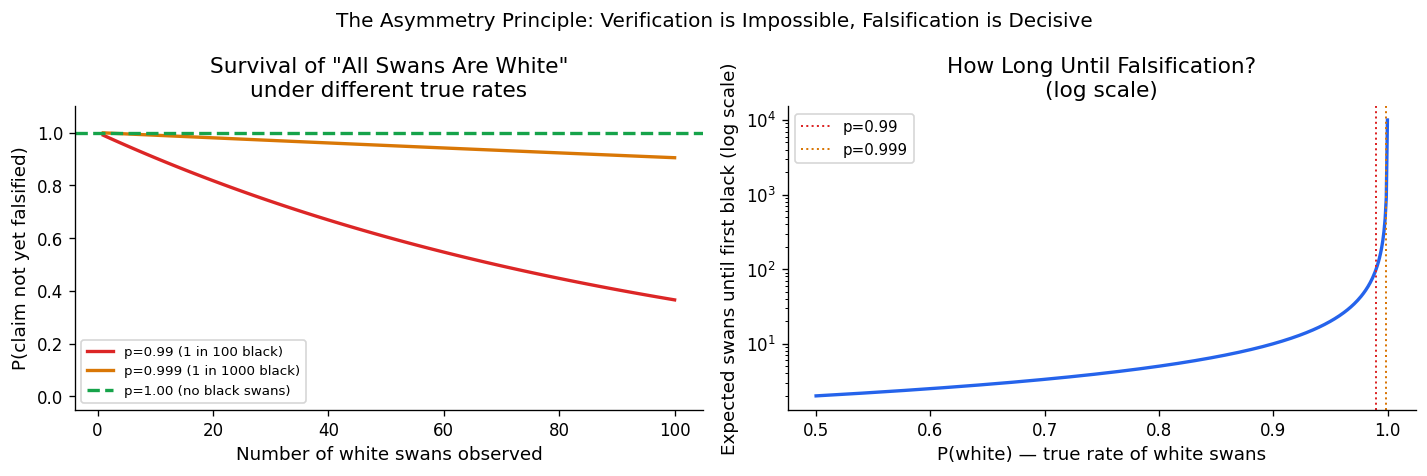

Key insight:
  No finite run of white swans can VERIFY the claim — even p=0.9999 means falsification is just slow.
  A single black swan IMMEDIATELY falsifies it — regardless of how many white ones came before.


In [3]:
def simulate_swan_sampling(p_white, n_swans, n_sims=10_000):
    """
    For each simulation, draw n_swans swans.
    Returns: array of shape (n_sims,) where entry i = first black swan index (or n_swans if none found).
    """
    draws = np.random.rand(n_sims, n_swans) < p_white  # True = white
    # For each row, find the first False (black swan)
    falsified_at = []
    for row in draws:
        idx = np.argmin(row)  # index of first False
        falsified_at.append(idx if not row[idx] else n_swans)
    return np.array(falsified_at)

N = 100
scenarios = [
    ('p=0.99 (1 in 100 black)', 0.99, RED),
    ('p=0.999 (1 in 1000 black)', 0.999, GOLD),
    ('p=1.00 (no black swans)', 1.00, GREEN),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: survival curve — P(claim not yet falsified after k swans)
k_vals = np.arange(1, N + 1)
for label, p, col in scenarios:
    if p < 1.0:
        survival = (p ** k_vals)  # P(all k swans white)
        axes[0].plot(k_vals, survival, color=col, lw=2, label=label)
    else:
        axes[0].axhline(1.0, color=col, lw=2, ls='--', label=label)

axes[0].set_xlabel('Number of white swans observed')
axes[0].set_ylabel('P(claim not yet falsified)')
axes[0].set_title('Survival of "All Swans Are White"\nunder different true rates')
axes[0].legend(fontsize=8)
axes[0].set_ylim(-0.05, 1.1)

# Right: expected number of swans until falsification
p_vals = np.linspace(0.5, 0.9999, 500)
expected_to_falsify = 1 / (1 - p_vals)
axes[1].semilogy(p_vals, expected_to_falsify, color=BLUE, lw=2)
axes[1].set_xlabel('P(white) — true rate of white swans')
axes[1].set_ylabel('Expected swans until first black (log scale)')
axes[1].set_title('How Long Until Falsification?\n(log scale)')
axes[1].axvline(0.99, color=RED, ls=':', lw=1.2, label='p=0.99')
axes[1].axvline(0.999, color=GOLD, ls=':', lw=1.2, label='p=0.999')
axes[1].legend(fontsize=9)

plt.suptitle('The Asymmetry Principle: Verification is Impossible, Falsification is Decisive', fontsize=12)
plt.tight_layout()
plt.show()

print('Key insight:')
print('  No finite run of white swans can VERIFY the claim — even p=0.9999 means falsification is just slow.')
print('  A single black swan IMMEDIATELY falsifies it — regardless of how many white ones came before.')

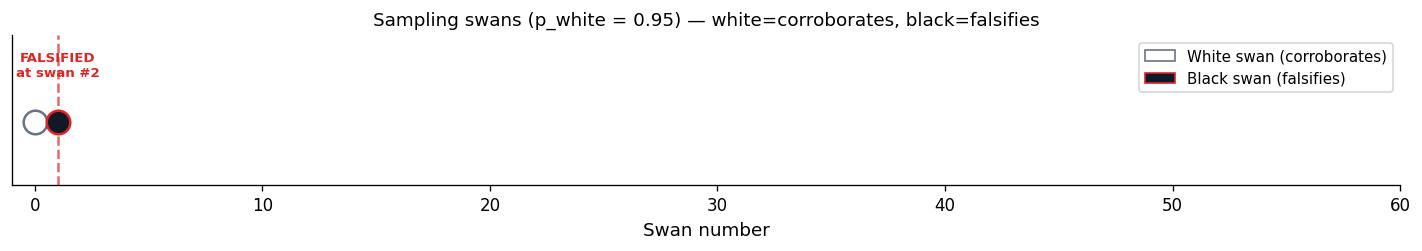

In [4]:
# Visualize a single sampling run: mark the moment of falsification
p_white = 0.95
n_show  = 60
swans   = (np.random.rand(n_show) < p_white).astype(int)  # 1=white, 0=black

fig, ax = plt.subplots(figsize=(12, 2.2))
for i, s in enumerate(swans):
    colour = 'white' if s == 1 else BLACK
    edge   = GRAY if s == 1 else RED
    ax.scatter(i, 0.5, s=200, color=colour, edgecolors=edge, linewidths=1.5, zorder=3)
    if s == 0:
        ax.axvline(i, color=RED, ls='--', lw=1.5, alpha=0.7)
        ax.text(i, 0.85, 'FALSIFIED\nat swan #{}'.format(i+1),
                ha='center', va='bottom', fontsize=8, color=RED, fontweight='bold')
        break

ax.set_xlim(-1, n_show)
ax.set_ylim(0, 1.2)
ax.set_yticks([])
ax.set_xlabel('Swan number')
ax.set_title(f'Sampling swans (p_white = {p_white}) — white=corroborates, black=falsifies', fontsize=11)

white_patch = mpatches.Patch(facecolor='white', edgecolor=GRAY, label='White swan (corroborates)')
black_patch = mpatches.Patch(facecolor=BLACK,  edgecolor=RED,  label='Black swan (falsifies)')
ax.legend(handles=[white_patch, black_patch], fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

<a id='3'></a>
## 3. Falsifiability Classifier — Scoring Statements

Popper's demarcation criterion distinguishes science from pseudo-science based on **falsifiability** and **boldness** of predictions.

We score a set of statements from the slides on two dimensions:
- **Falsifiability** (0 = not falsifiable, 1 = falsifiable)
- **Boldness** (how risky/specific the prediction is, 0–10)

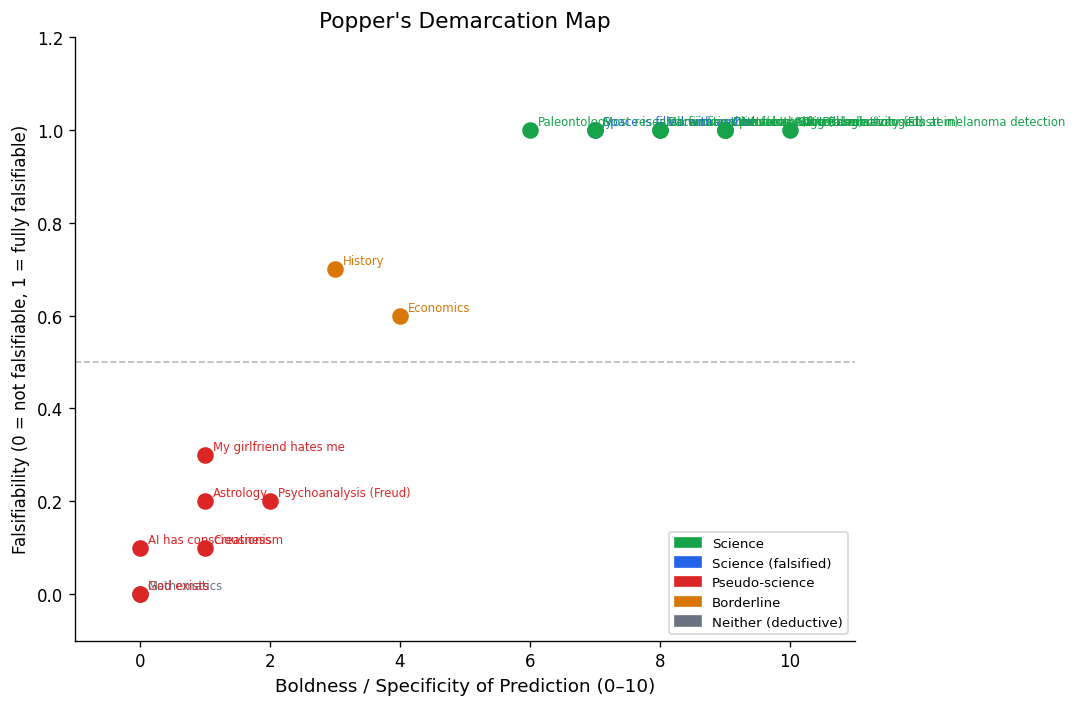

Science lives in the upper-right: highly falsifiable AND bold predictions.
Pseudo-science is in the lower-left: unfalsifiable or vague.


In [5]:
statements = pd.DataFrame([
    # From slides: Science or Pseudo-science?
    {'Statement': 'Astrology',                                           'Falsifiable': 0.2, 'Boldness': 1, 'Category': 'Pseudo-science'},
    {'Statement': 'Creationism',                                         'Falsifiable': 0.1, 'Boldness': 1, 'Category': 'Pseudo-science'},
    {'Statement': 'Darwinian evolution / Natural selection',             'Falsifiable': 1.0, 'Boldness': 8, 'Category': 'Science'},
    {'Statement': 'Mathematics',                                         'Falsifiable': 0.0, 'Boldness': 0, 'Category': 'Neither (deductive)'},
    {'Statement': 'Paleontology',                                        'Falsifiable': 1.0, 'Boldness': 6, 'Category': 'Science'},
    {'Statement': 'Economics',                                           'Falsifiable': 0.6, 'Boldness': 4, 'Category': 'Borderline'},
    {'Statement': 'History',                                             'Falsifiable': 0.7, 'Boldness': 3, 'Category': 'Borderline'},
    {'Statement': 'Climate change (human-caused)',                       'Falsifiable': 1.0, 'Boldness': 9, 'Category': 'Science'},
    {'Statement': 'Cosmology (Big Bang)',                                'Falsifiable': 1.0, 'Boldness': 9, 'Category': 'Science'},
    # From slides: Falsifiable statements?
    {'Statement': 'God exists',                                          'Falsifiable': 0.0, 'Boldness': 0, 'Category': 'Pseudo-science'},
    {'Statement': 'Vaccination prevents COVID',                         'Falsifiable': 1.0, 'Boldness': 8, 'Category': 'Science'},
    {'Statement': 'Space is filled with aether',                        'Falsifiable': 1.0, 'Boldness': 7, 'Category': 'Science (falsified)'},
    {'Statement': 'My girlfriend hates me',                             'Falsifiable': 0.3, 'Boldness': 1, 'Category': 'Pseudo-science'},
    {'Statement': 'Most research findings are false',                   'Falsifiable': 1.0, 'Boldness': 7, 'Category': 'Science'},
    {'Statement': 'DNNs outperform dermatologists at melanoma detection','Falsifiable': 1.0, 'Boldness': 9, 'Category': 'Science'},
    {'Statement': 'AI has consciousness',                               'Falsifiable': 0.1, 'Boldness': 0, 'Category': 'Pseudo-science'},
    {'Statement': 'Psychoanalysis (Freud)',                             'Falsifiable': 0.2, 'Boldness': 2, 'Category': 'Pseudo-science'},
    {'Statement': 'General relativity (Einstein)',                      'Falsifiable': 1.0, 'Boldness': 10,'Category': 'Science'},
])

colour_map = {
    'Science':               GREEN,
    'Science (falsified)':   BLUE,
    'Pseudo-science':        RED,
    'Borderline':            GOLD,
    'Neither (deductive)':   GRAY,
}

fig, ax = plt.subplots(figsize=(9, 6))
for _, row in statements.iterrows():
    col = colour_map[row['Category']]
    ax.scatter(row['Boldness'], row['Falsifiable'], color=col, s=80, zorder=3)
    ax.annotate(row['Statement'], (row['Boldness'], row['Falsifiable']),
                textcoords='offset points', xytext=(5, 3), fontsize=7, color=col)

ax.axhline(0.5, color=GRAY, ls='--', lw=1, alpha=0.5, label='Falsifiability threshold')
ax.set_xlabel('Boldness / Specificity of Prediction (0–10)', fontsize=11)
ax.set_ylabel('Falsifiability (0 = not falsifiable, 1 = fully falsifiable)', fontsize=10)
ax.set_title("Popper's Demarcation Map", fontsize=13)
ax.set_xlim(-1, 11)
ax.set_ylim(-0.1, 1.2)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colour_map.items()]
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

print('Science lives in the upper-right: highly falsifiable AND bold predictions.')
print('Pseudo-science is in the lower-left: unfalsifiable or vague.')

<a id='4'></a>
## 4. Popper ↔ Hypothesis Testing — Step-by-Step

Statistical hypothesis testing is Popperian falsification made quantitative.  
Here we walk through the exact mapping on a concrete example: *does a new drug reduce blood pressure?*

In [6]:
mapping = pd.DataFrame([
    {'Popper Step':          'Current theory',
     'Statistics Equivalent':'Null hypothesis $H_0$',
     'Our Example':          '$H_0$: drug has no effect ($\\mu = 0$ mmHg reduction)'},
    {'Popper Step':          'Derive risky prediction',
     'Statistics Equivalent':'Define test statistic & critical region',
     'Our Example':          'Reject $H_0$ if $|\\bar{X}| > 1.96 \\cdot SE$ (two-sided, $\\alpha=0.05$)'},
    {'Popper Step':          'Basic statement (observable)',
     'Statistics Equivalent':'Collect data, compute test statistic',
     'Our Example':          'Observe mean reduction $\\bar{X}$ in $n=50$ patients'},
    {'Popper Step':          'Falsification',
     'Statistics Equivalent':'Reject $H_0$ (p-value < $\\alpha$)',
     'Our Example':          'p = 0.013 < 0.05 → reject $H_0$; drug has an effect'},
    {'Popper Step':          'Corroboration (no falsification)',
     'Statistics Equivalent':'Fail to reject $H_0$',
     'Our Example':          'p = 0.34 → cannot conclude drug works'},
    {'Popper Step':          'New theory to test',
     'Statistics Equivalent':'$H_A$ becomes the new $H_0$',
     'Our Example':          'New $H_0$: drug reduces BP by exactly 5 mmHg → test this'},
])

print(mapping.to_string(index=False))

                     Popper Step                   Statistics Equivalent                                                            Our Example
                  Current theory                   Null hypothesis $H_0$                   $H_0$: drug has no effect ($\mu = 0$ mmHg reduction)
         Derive risky prediction Define test statistic & critical region Reject $H_0$ if $|\bar{X}| > 1.96 \cdot SE$ (two-sided, $\alpha=0.05$)
    Basic statement (observable)    Collect data, compute test statistic                    Observe mean reduction $\bar{X}$ in $n=50$ patients
                   Falsification       Reject $H_0$ (p-value < $\alpha$)                    p = 0.013 < 0.05 → reject $H_0$; drug has an effect
Corroboration (no falsification)                    Fail to reject $H_0$                                  p = 0.34 → cannot conclude drug works
              New theory to test             $H_A$ becomes the new $H_0$               New $H_0$: drug reduces BP by exactly 5 mmHg → te

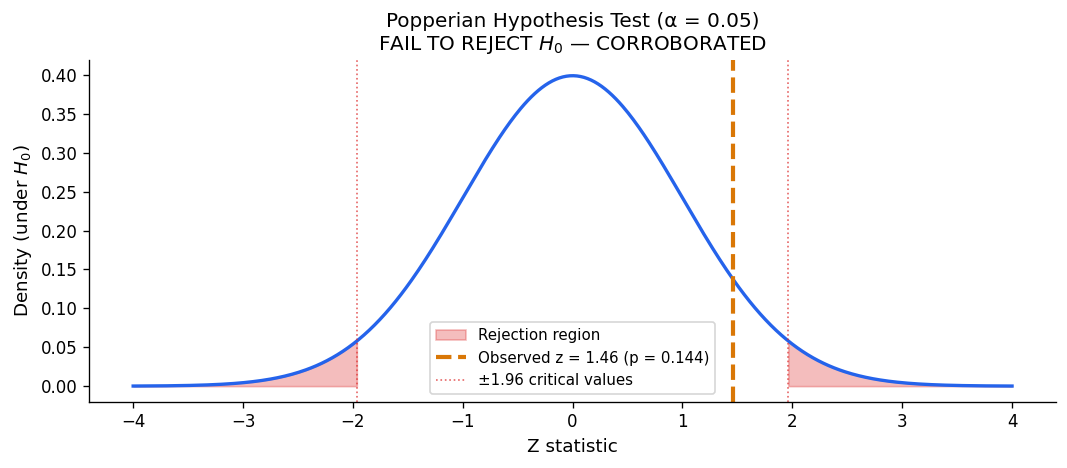

Sample mean reduction: 2.07 mmHg
Z statistic:           1.46
P-value:               0.1440
Decision:              Fail to reject H0
True effect:           3.0 mmHg  ← unknown to analyst


In [7]:
# Simulate the drug trial and visualize the Popperian decision
TRUE_EFFECT = 3.0   # mmHg (unknown to the analyst)
SIGMA       = 10.0  # std dev
N           = 50
ALPHA       = 0.05

np.random.seed(7)
data        = np.random.normal(TRUE_EFFECT, SIGMA, N)
x_bar       = data.mean()
se          = SIGMA / np.sqrt(N)
z_stat      = x_bar / se
p_value     = 2 * (1 - norm.cdf(abs(z_stat)))
critical_z  = norm.ppf(1 - ALPHA / 2)

z_vals      = np.linspace(-4, 4, 500)
pdf_vals    = norm.pdf(z_vals)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(z_vals, pdf_vals, color=BLUE, lw=2)
ax.fill_between(z_vals, pdf_vals, where=(z_vals > critical_z),  color=RED, alpha=0.3, label='Rejection region')
ax.fill_between(z_vals, pdf_vals, where=(z_vals < -critical_z), color=RED, alpha=0.3)
ax.axvline(z_stat, color=GREEN if abs(z_stat) > critical_z else GOLD,
           lw=2.5, ls='--',
           label=f'Observed z = {z_stat:.2f} (p = {p_value:.3f})')
ax.axvline( critical_z, color=RED, lw=1, ls=':', alpha=0.7, label=f'±{critical_z:.2f} critical values')
ax.axvline(-critical_z, color=RED, lw=1, ls=':', alpha=0.7)

decision = 'REJECT $H_0$ — FALSIFIED' if abs(z_stat) > critical_z else 'FAIL TO REJECT $H_0$ — CORROBORATED'
ax.set_title(f'Popperian Hypothesis Test (α = {ALPHA})\n{decision}', fontsize=12)
ax.set_xlabel('Z statistic')
ax.set_ylabel('Density (under $H_0$)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Sample mean reduction: {x_bar:.2f} mmHg')
print(f'Z statistic:           {z_stat:.2f}')
print(f'P-value:               {p_value:.4f}')
print(f'Decision:              {"Reject H0" if p_value < ALPHA else "Fail to reject H0"}')
print(f'True effect:           {TRUE_EFFECT} mmHg  ← unknown to analyst')

<a id='5'></a>
## 5. Ad Hoc Hypotheses and the Destruction of Falsifiability

Popper's demarcation criterion catches a common scientific vice: **saving a theory from refutation by adding ad hoc patches.**

Each patch makes the theory consistent with the new data — but also makes it less falsifiable, and eventually unfalsifiable.

We simulate this by counting how many ad hoc modifications inflate the probability of *always* surviving tests.

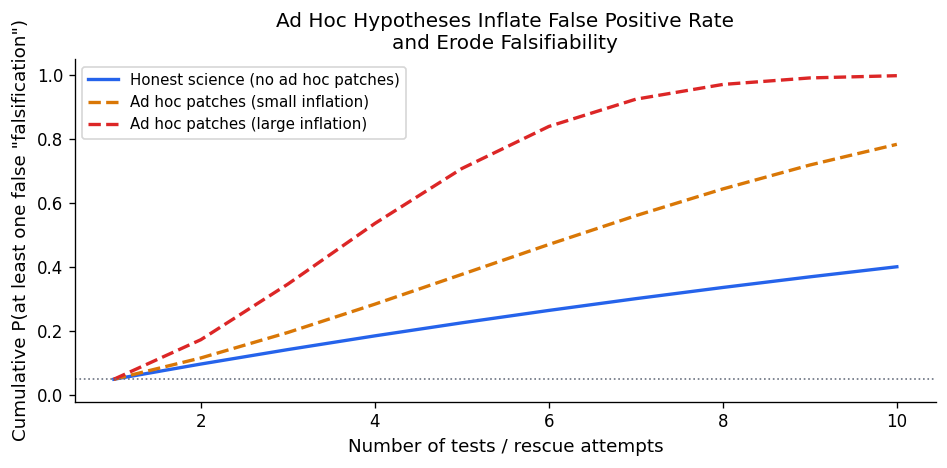

Honest science: FWER grows slowly but stays controlled.
Ad hoc patches: effective alpha inflates — theory becomes immune to falsification.

Popper's point: a theory that can always be rescued is not scientific.


In [8]:
# Suppose a theory makes a specific prediction with P(pass | theory true) = power = 0.8
# and P(pass | theory false) = alpha = 0.05 (false positive rate)
# Each ad hoc modification adds another "escape hatch" — effectively raising alpha.

# Imagine after each failed test the analyst adds 1 free parameter to rescue the theory.
# Each extra parameter costs 1 degree of freedom and inflates the effective alpha.

n_tests = 10
alpha_base = 0.05

# Scenario A: honest science — single pre-specified hypothesis
# P(reject at least once in n_tests | H0 true) = FWER
def fwer(alpha, n):
    return 1 - (1 - alpha) ** n

# Scenario B: after each failure, add 1 ad hoc fix — new effective alpha grows
def ad_hoc_fwer(alpha_base, n_tests, inflation_per_fix=0.05):
    """Each failed test that is 'rescued' inflates effective alpha by inflation_per_fix."""
    cumulative_false_positive = 0
    alpha_eff = alpha_base
    for _ in range(n_tests):
        cumulative_false_positive = 1 - (1 - cumulative_false_positive) * (1 - alpha_eff)
        alpha_eff = min(alpha_eff + inflation_per_fix, 1.0)
    return cumulative_false_positive

n_vals = np.arange(1, n_tests + 1)
honest_fwer     = [fwer(alpha_base, n) for n in n_vals]
adhoc_fwer_low  = [ad_hoc_fwer(alpha_base, n, inflation_per_fix=0.02) for n in n_vals]
adhoc_fwer_high = [ad_hoc_fwer(alpha_base, n, inflation_per_fix=0.08) for n in n_vals]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_vals, honest_fwer,     color=BLUE,   lw=2, label='Honest science (no ad hoc patches)')
ax.plot(n_vals, adhoc_fwer_low,  color=GOLD,   lw=2, ls='--', label='Ad hoc patches (small inflation)')
ax.plot(n_vals, adhoc_fwer_high, color=RED,    lw=2, ls='--', label='Ad hoc patches (large inflation)')
ax.axhline(0.05, color=GRAY, ls=':', lw=1)
ax.set_xlabel('Number of tests / rescue attempts')
ax.set_ylabel('Cumulative P(at least one false "falsification")')
ax.set_title('Ad Hoc Hypotheses Inflate False Positive Rate\nand Erode Falsifiability', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

print('Honest science: FWER grows slowly but stays controlled.')
print('Ad hoc patches: effective alpha inflates — theory becomes immune to falsification.')
print('\nPopper\'s point: a theory that can always be rescued is not scientific.')

In [9]:
# Concrete example: Freudian vs. Einsteinian predictions
examples = pd.DataFrame([
    {'Theory':     'Psychoanalysis',
     'Prediction': 'Neurotic behavior stems from repressed childhood trauma',
     'Outcome A':  'Patient shows neurotic behavior → CONFIRMS (childhood trauma repressed)',
     'Outcome B':  'Patient shows no neurotic behavior → ALSO CONFIRMS (trauma successfully repressed)',
     'Verdict':    'Unfalsifiable — explains all outcomes'},
    {'Theory':     'General Relativity',
     'Prediction': 'Light from a distant star bends 1.75" passing the sun',
     'Outcome A':  'Eddington (1919) measures 1.61"–1.98" bending → CORROBORATES',
     'Outcome B':  'If measured 0" bending → FALSIFIES the entire theory',
     'Verdict':    'Falsifiable — specific, risky, bold prediction'},
    {'Theory':     'Marxism (dogmatic form)',
     'Prediction': 'Capitalism will inevitably collapse',
     'Outcome A':  'Economic crisis occurs → CONFIRMS',
     'Outcome B':  'No crisis → "Dialectical step" or "bourgeoisie manipulation" → ALSO CONFIRMS',
     'Verdict':    'Unfalsifiable — all evidence is reinterpreted as support'},
])

for _, row in examples.iterrows():
    print(f"Theory:     {row['Theory']}")
    print(f"Prediction: {row['Prediction']}")
    print(f"Outcome A:  {row['Outcome A']}")
    print(f"Outcome B:  {row['Outcome B']}")
    print(f"Verdict:    {row['Verdict']}")
    print()

Theory:     Psychoanalysis
Prediction: Neurotic behavior stems from repressed childhood trauma
Outcome A:  Patient shows neurotic behavior → CONFIRMS (childhood trauma repressed)
Outcome B:  Patient shows no neurotic behavior → ALSO CONFIRMS (trauma successfully repressed)
Verdict:    Unfalsifiable — explains all outcomes

Theory:     General Relativity
Prediction: Light from a distant star bends 1.75" passing the sun
Outcome A:  Eddington (1919) measures 1.61"–1.98" bending → CORROBORATES
Outcome B:  If measured 0" bending → FALSIFIES the entire theory
Verdict:    Falsifiable — specific, risky, bold prediction

Theory:     Marxism (dogmatic form)
Prediction: Capitalism will inevitably collapse
Outcome A:  Economic crisis occurs → CONFIRMS
Outcome B:  No crisis → "Dialectical step" or "bourgeoisie manipulation" → ALSO CONFIRMS
Verdict:    Unfalsifiable — all evidence is reinterpreted as support



<a id='6'></a>
## 6. The Evolution of Science — A Toy Model

Popper viewed science as an evolutionary process: theories compete, the better-corroborated ones survive, knowledge grows by discarding what is false.

We simulate a population of competing theories, each making predictions of varying boldness, and track which survive repeated critical tests.

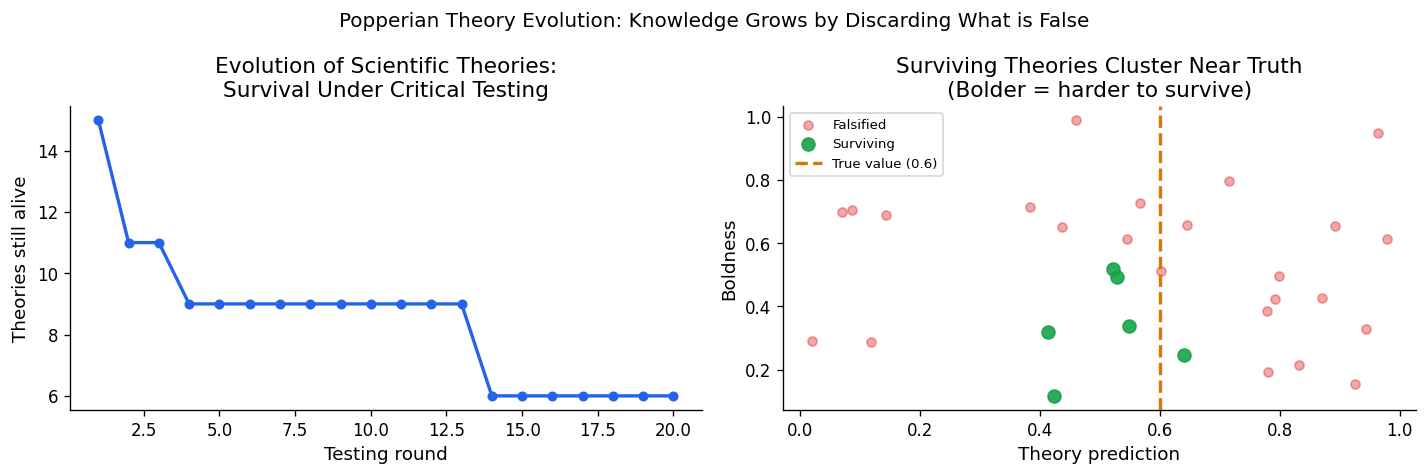

True effect: 0.6
Surviving theories: 6
Mean prediction of survivors: 0.513
Mean boldness of survivors:   0.339


In [10]:
np.random.seed(0)

N_THEORIES   = 30   # initial theory pool
N_ROUNDS     = 20   # rounds of testing
TRUE_EFFECT  = 0.6  # hidden truth in [0,1]

# Each theory has a 'prediction' in [0,1] and a 'boldness' (how specific/risky)
theories = pd.DataFrame({
    'id':        np.arange(N_THEORIES),
    'prediction': np.random.uniform(0, 1, N_THEORIES),
    'boldness':   np.random.uniform(0.1, 1.0, N_THEORIES),
    'alive':      True,
    'survived':   0,
})

history = []

for rnd in range(N_ROUNDS):
    # Observation: noisy measurement of TRUE_EFFECT
    observation = TRUE_EFFECT + np.random.normal(0, 0.15)

    # A theory is falsified if its prediction is far from the observation,
    # scaled by its boldness (bolder theories are falsified more easily)
    alive_mask = theories['alive'].values.copy()
    for i, row in theories[theories['alive']].iterrows():
        error = abs(row['prediction'] - observation)
        threshold = 0.5 * (1 - row['boldness'])  # bolder = lower tolerance for error
        if error > threshold:
            theories.at[i, 'alive'] = False  # falsified
        else:
            theories.at[i, 'survived'] += 1

    n_alive = theories['alive'].sum()
    history.append({'round': rnd + 1, 'alive': n_alive})

    # Spawn new theories near surviving ones (like mutation)
    if n_alive > 0 and n_alive < 5:
        survivors = theories[theories['alive']]
        new_rows = []
        for _ in range(3):
            parent = survivors.sample(1).iloc[0]
            new_rows.append({
                'id': len(theories) + len(new_rows),
                'prediction': np.clip(parent['prediction'] + np.random.normal(0, 0.05), 0, 1),
                'boldness':   np.clip(parent['boldness']   + np.random.normal(0, 0.05), 0.1, 1),
                'alive':      True,
                'survived':   0,
            })
        theories = pd.concat([theories, pd.DataFrame(new_rows)], ignore_index=True)

history_df = pd.DataFrame(history)

# Plot 1: number of surviving theories over rounds
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df['round'], history_df['alive'], color=BLUE, lw=2, marker='o', ms=5)
axes[0].set_xlabel('Testing round')
axes[0].set_ylabel('Theories still alive')
axes[0].set_title('Evolution of Scientific Theories:\nSurvival Under Critical Testing')

# Plot 2: surviving theories cluster near the truth
alive_th = theories[theories['alive']]
dead_th  = theories[~theories['alive']]
axes[1].scatter(dead_th['prediction'],  dead_th['boldness'],  color=RED,   alpha=0.4, s=30, label='Falsified')
axes[1].scatter(alive_th['prediction'], alive_th['boldness'], color=GREEN, alpha=0.9, s=60, label='Surviving')
axes[1].axvline(TRUE_EFFECT, color=GOLD, lw=2, ls='--', label=f'True value ({TRUE_EFFECT})')
axes[1].set_xlabel('Theory prediction')
axes[1].set_ylabel('Boldness')
axes[1].set_title('Surviving Theories Cluster Near Truth\n(Bolder = harder to survive)')
axes[1].legend(fontsize=8)

plt.suptitle('Popperian Theory Evolution: Knowledge Grows by Discarding What is False', fontsize=12)
plt.tight_layout()
plt.show()

print(f'True effect: {TRUE_EFFECT}')
print(f'Surviving theories: {len(alive_th)}')
if len(alive_th) > 0:
    print(f'Mean prediction of survivors: {alive_th["prediction"].mean():.3f}')
    print(f'Mean boldness of survivors:   {alive_th["boldness"].mean():.3f}')

<a id='7'></a>
## 7. Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **Falsifiability** | A theory is scientific iff it makes at least one prediction that could be proven false |
| **Asymmetry principle** | Verification is logically impossible; falsification is logically decisive |
| **Against induction** | No finite observation set can prove a universal law; theory comes first, testing follows |
| **Corroboration ≠ verification** | Surviving tests raises confidence; it does not prove truth |
| **Basic statement** | A formally accepted potential falsifier — observable, reproducible, agreed by convention |
| **Science vs. pseudo-science** | Science makes bold, risky, specific predictions; pseudo-science explains everything after the fact |
| **Ad hoc hypotheses** | Rescuing a theory by patching anomalies destroys its falsifiability — and its scientific status |
| **Hypothesis testing is Popperian** | $H_0$ = current theory; reject = falsify; fail to reject = corroborate; $H_A$ becomes the new $H_0$ |
| **Propensity theory** | Popper's third view: probability as the physical tendency of an experimental setup, not frequency or belief |
| **Evolution of science** | Knowledge grows by eliminating false theories, not accumulating confirmations |

---

## 📚 References

- Popper, K. (1934/1959). *The Logic of Scientific Discovery.* Hutchinson.
- Popper, K. (1963). *Conjectures and Refutations.* Routledge.
- Lakatos, I. (1978). *The Methodology of Scientific Research Programmes.* Cambridge.
- Mayo, D.G. (2018). *Statistical Inference as Severe Testing.* Cambridge University Press.

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*